# Email Segregator

For my capstone project, I've decided to create an **email segregator**, that intends to **classify important mails differently than spam, phishing, unnecessary, or confusing mails**, which **wastes the time of a user** and causes them **digital exhaustion, decreased efficiency.**

## Initial Setup👇

These are all the essential libraries I'll need to import in order to start programing the model of the email segregator. These libraries are essential for **data handling, natural language processing (NLP), machine learning (ML), and visualization**

In [1]:
# Main Data Handling
import pandas as pd #For loading and manipulating your email dataset
import numpy as np  #For numerical operations and handling arrays

#Natural Language Processing (NLP)
import nltk         # Is the Natural Language Toolkit for text processing
import spacy        # Is a library designed for advanced Natural Language Processing
from nltk.corpus import stopwords, wordnet # To filter out the common, non-essential words
from nltk.stem import WordNetLemmatizer # To reduce the words to their base dictionary form

from sklearn.preprocessing import MinMaxScaler # To scale numerical features to a common range

#Machine Learning Models
from sklearn.linear_model import LogisticRegression # Imports Logistic Regression Model
from sklearn.ensemble import RandomForestClassifier # Imports Random Forest Model
from sklearn.svm import SVC # Imports Support Vector Classifier (SVM)
from sklearn.naive_bayes import MultinomialNB # Imports Multinomial Naive Bayes Classifier

#Machine Learning Evaluation
from sklearn.metrics import classification_report #Classification performance report

#Data Visualisation
import matplotlib.pyplot as plt #Helps for plotting and visualisation

# Download Required NLTK Resources
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')                # Required for Stop Word Removal: filters common words like "the" and "is"
nltk.download('wordnet')                  # Required for Lemmatization: reducing words to their base dictionary form
nltk.download('averaged_perceptron_tagger_eng') # Required for Parts of Speech (POS) tagging: identifying nouns, verbs, etc.

print("Imports successful!")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Imports successful!


## Loading the dataset

Now I will need to load my data set into a **Pandas DataFrame**

This will turn the CSV file into a table I can manipulate

In [2]:
#Import the GDrive Module from Google Colab
from google.colab import drive

#Mounting the GDrive to access files stored in it
drive.mount('/content/drive', force_remount=True)

#Load the spam dataset from Google Drive into a Pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/Email_Segregator(Capstone Project)/Spam_Data_Classification_Project.csv')

#Displaying the first five rows of the dataset to see how it looks
df.head()

Mounted at /content/drive


,CATEGORY,MESSAGE,FILE_NAME
0,1,"Dear Homeowner,\n\n \n\nInterest Rates are at ...",00249.5f45607c1bffe89f60ba1ec9f878039a
1,1,ATTENTION: This is a MUST for ALL Computer Use...,00373.ebe8670ac56b04125c25100a36ab0510
2,1,This is a multi-part message in MIME format.\n...,00214.1367039e50dc6b7adb0f2aa8aba83216
3,1,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...,00210.050ffd105bd4e006771ee63cabc59978
4,1,This is the bottom line. If you can GIVE AWAY...,00033.9babb58d9298daa2963d4f514193d7d6


## Preprossesing

**Here I'll start cleaning, transforming, and organizing the email data into more a structured format so the final machine learning model can accurately process the emails.**

In [3]:
# This code creates a tokenizer that extracts words using a regular expression
# The pattern `\w+` matches the sequences of alphanumeric characters (letters, numbers, and underscores)
tokenizer = nltk.RegexpTokenizer(r"\w+")

# This is a sample text message with punctuation, HTML tags, and junk content
test_message = "Yo,,  wwhere you at? <HTML><junk> it's running junk just messily placedddddjhjj...,</junk></HTML>"

# This tokenizes the message, by extract words while removing punctuation, HTML tags, and special characters
test_message_tokenized = tokenizer.tokenize(test_message)

# This displays the tokenized output as a list of words
test_message_tokenized

['Yo',
 'wwhere',
 'you',
 'at',
 'HTML',
 'junk',
 'it',
 's',
 'running',
 'junk',
 'just',
 'messily',
 'placedddddjhjj',
 'junk',
 'HTML']

In [4]:
# This converts all the tokens to lowercase to ensure uniformity and case insensitivity(Which means uppercase (capital) and lowercase (small) letters are treated as identical.)
# This helps in the text processing by treating words like "Hello" and "hello" as the same
test_message_lowercased = [t.lower() for t in test_message_tokenized]

# Displays the list of lowercased tokens
test_message_lowercased

['yo',
 'wwhere',
 'you',
 'at',
 'html',
 'junk',
 'it',
 's',
 'running',
 'junk',
 'just',
 'messily',
 'placedddddjhjj',
 'junk',
 'html']

In [5]:
# Loads the spaCy English model
nlp = spacy.load('en_core_web_sm')

# This applies lemmatization to each of the tokens in the lowercased token list
# This helps reduce words like "running" or "better" to their base forms which is "run" and "good"
text = ' '.join(test_message_lowercased)

# Processing the text using spaCy
doc = nlp(text)

# This extracts the lemmatized tokens
lemmatized_tokens = [token.lemma_ for token in doc]

print("Lemmatized Words:", lemmatized_tokens)

Lemmatized Words: ['yo', 'wwhere', 'you', 'at', 'html', 'junk', 'it', 's', 'run', 'junk', 'just', 'messily', 'placedddddjhjj', 'junk', 'html']


In [6]:
# This get a list of common English stopwords (words like 'the', 'and', 'is', etc.)
# These are usually removed during the text processing as they don't carry significant meaning
stopwords = stopwords.words('english')

# Display the list of English stopwords
stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [7]:
# List of HTML-related tokens
# These terms might be included in the text, but are typically not relevant to the analysis
html_tokens = [
    "font", "td", "br", "size", "b", "tr", "p", "face", "color", "width", "align",
    "center", "height", "table", "border", "href", "u", "html", "style", "div",
    "bgcolor", "src", "img", "value", "option", "text", "type", "span", "content",
    "body", "cellspacing", "li", "cellpadding", "blockquote", "input", "valign",
    "address", "strong", "left", "margin", "head", "order", "colspan", "title",
    "form", "tbody", "class", "alt", "meta", "link", "background", "id", "title",
    "name", "method", "action", "lang", "hidden", "submit", "padding", "document",
    "search", "server", "target", "hr", "ul", "em", "select", "small", "red",
    "plain", "option", "bordercolor", "charset", "equiv", "decoration", "label",
    "nbsp", "ptsize", "3d", "html", "-"
]

# Extend the list of stopwords with HTML-related tokens
# This ensures that both common stopwords and HTML-specific terms are removed from the text
stopwords.extend(html_tokens)

# Display the updated list of stopwords (now includes both common and HTML-related terms)
stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [8]:
# Filters the lemmatized tokens to remove any words that are in the stopwords list
# This step ensures that only the meaningful words would remain in the tokenized message
# Words like common stopwords and HTML-related terms will be excluded
test_message_useful_tokens = [t for t in lemmatized_tokens if t not in stopwords]

# Displays the list of useful tokens (tokens that are not stopwords)
test_message_useful_tokens

['yo', 'wwhere', 'junk', 'run', 'junk', 'messily', 'placedddddjhjj', 'junk']

In [9]:
# Loads the spay English model
nlp = spacy.load('en_core_web_sm')

# Now I define a function that converts a message to a list of useful tokens
# THe function tokenizes, lowers case, lemmatizes, and removes stopwords from the input message
def message_to_token_list(s):
    # Tokenizes the input string `s` into individual words using the tokenizer
    tokens = tokenizer.tokenize(s)

    # THis converts all tokens to lowercase for uniformity and case-insensitive processing
    lowercased_tokens = [t.lower() for t in tokens]

    # Lemmatize each token to get its base or root form (e.g., "running" -> "run")
    text = ' '.join(lowercased_tokens)

    # Process the text using spaCy
    doc = nlp(text)

    # Extract the lemmatized tokens
    lemmatized_tokens = [token.lemma_ for token in doc]

    # this removes stopwords and other irrelevant tokens (like HTML tags)
    useful_tokens = [t for t in lemmatized_tokens if t not in stopwords]

    # Returns the list of useful tokens
    return useful_tokens

# THis calls the function `message_to_token_list` on the test message so O can get the list of useful tokens
message_to_token_list(test_message)

['yo', 'wwhere', 'junk', 'run', 'junk', 'messily', 'placedddddjhjj', 'junk']

## Most Common Tokens in Non-Spam Emails

This helps me understand what **words are most commonly used in emails that aren't spam**

In [10]:
# This is an empty dictionary that will store the token counts
token_counter = {}

# THis iterates over each row in the DataFrame `df`
# The `iterrows` function gives both index and the row data
for index, row in df.iterrows():

    # This line checks if the message belongs to the 'Non-Spam Emails' category(0)
    if row['CATEGORY'] == 0:

        # One the check of the category of the message is done, this line converts the message into a list of useful tokens using the `message_to_token_list` function
        message_as_token_lst = message_to_token_list(row['MESSAGE'])

        # This line iterates over each token in the tokenized message
        for token in message_as_token_lst:

            # If the token already exists in the token_counter dictionary, this code increments its count
            if token in token_counter:
                token_counter[token] += 1
            else:
                # If the token doesn't exist in the dictionary, this line of code initializes its count to 1
                token_counter[token] = 1

# This line prints the total number of unique tokens encountered in non-spam emails by checking the dictionary length
len(token_counter)

36066

**List of Most commonly used words to Least commonly used words in non-spam emails**



In [11]:
# This sorts the token_counter dictionary by its values (the token counts) in descending order
# The `sorted()` function sorts the items based on the second element of each tuple (the count)
sorted_tokens = dict(sorted(token_counter.items(), key=lambda item: item[1], reverse=True))

# Displays the sorted dictionary of tokens and their counts
sorted_tokens

{'_': 69216,
 'I': 14684,
 'http': 7089,
 'list': 6567,
 'com': 6400,
 'net': 4257,
 'www': 3725,
 '0': 3724,
 'use': 3669,
 'linux': 3627,
 '1': 3565,
 '2002': 3168,
 'get': 2958,
 'user': 2854,
 '2': 2661,
 'listinfo': 2450,
 'one': 2447,
 'write': 2361,
 'ie': 2349,
 'say': 2241,
 'rpm': 2152,
 'message': 2019,
 'mailman': 1951,
 'would': 1905,
 'make': 1843,
 'work': 1824,
 'time': 1824,
 'like': 1816,
 'file': 1631,
 'razor': 1625,
 'new': 1598,
 'go': 1556,
 'spamassassin': 1554,
 'org': 1543,
 'people': 1498,
 'well': 1461,
 'mailing': 1439,
 'think': 1431,
 'group': 1416,
 'exmh': 1367,
 'ilug': 1327,
 '3': 1326,
 'know': 1321,
 'see': 1316,
 'email': 1304,
 'spam': 1277,
 'sourceforge': 1266,
 'change': 1252,
 'mail': 1250,
 'system': 1216,
 'find': 1202,
 'also': 1184,
 'good': 1166,
 'way': 1164,
 'run': 1157,
 'freshrpm': 1152,
 '10': 1152,
 '4': 1122,
 'information': 1117,
 'date': 1101,
 'need': 1092,
 'look': 1088,
 '00': 1083,
 'could': 1061,
 'want': 1045,
 'take': 103

**Histogram of Top 50 commonly used words in Non-Spam Emails**

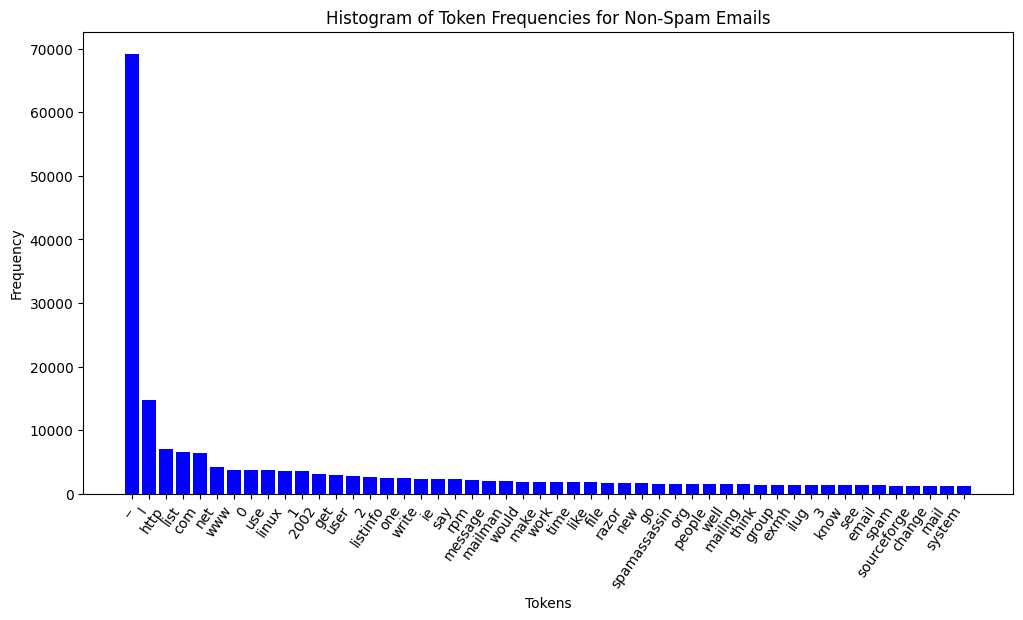

In [12]:
# This extracts the top 50 most frequent tokens (keys) and their corresponding frequencies (values)
keys = list(sorted_tokens.keys())[:50]  # Gets the top 50 tokens
values = list(sorted_tokens.values())[:50]  # Gets the corresponding frequencies of the top 50 tokens

# This sets the figure size for the plot (12 inches wide by 6 inches tall)
plt.figure(figsize=(12, 6))

# This creates a bar chart (histogram) to visualize the token frequencies
# The `keys` are the tokens, and the `values` are their respective frequencies
plt.bar(keys, values, color='blue')

# Adding labels and a title to the plot
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.xticks(rotation=55, ha="right", fontsize=10)
plt.title("Histogram of Token Frequencies for Non-Spam Emails")

# Displays the plot
plt.show()

## Most Common Tokens in Spam Emails

This helps me understand what **words are most commonly used in emails that are spam**

In [13]:
# This is an empty dictionary that will store the token counts
token_counter = {}

# THis iterates over each row in the DataFrame `df`
# The `iterrows` function gives both index and the row data
for index, row in df.iterrows():

    # This line checks if the message belongs to the 'Spam Emails' category(1)
    if row['CATEGORY'] == 1:

        # One the check of the category of the message is done, this line converts the message into a list of useful tokens using the `message_to_token_list` function
        message_as_token_lst = message_to_token_list(row['MESSAGE'])

        # This line iterates over each token in the tokenized message
        for token in message_as_token_lst:

            # If the token already exists in the token_counter dictionary, this code increments its count
            if token in token_counter:
                token_counter[token] += 1
            else:
                # If the token doesn't exist in the dictionary, this line of code initializes its count to 1
                token_counter[token] = 1

# This line prints the total number of unique tokens encountered in non-spam emails by checking the dictionary length
len(token_counter)

69152

**List of Most commonly used words to Least commonly used words in spam emails**

In [14]:
# This sorts the token_counter dictionary by its values (the token counts) in descending order
# The `sorted()` function sorts the items based on the second element of each tuple (the count)
sorted_tokens = dict(sorted(token_counter.items(), key=lambda item: item[1], reverse=True))

# Displays the sorted dictionary of tokens and their counts
sorted_tokens

{'_': 41334,
 'http': 11330,
 'com': 8782,
 '0': 8699,
 'I': 7734,
 '1': 7549,
 '2': 7346,
 'arial': 7232,
 '20': 6969,
 'www': 6253,
 'helvetica': 3981,
 'verdana': 3916,
 'email': 3648,
 'serif': 3609,
 '3e': 3594,
 '22': 3461,
 'sans': 3401,
 '3': 3179,
 'ffffff': 2939,
 '5': 2897,
 'free': 2828,
 '4': 2786,
 'list': 2538,
 'e': 2494,
 'gif': 2442,
 'net': 2418,
 'mail': 2346,
 '000000': 2302,
 '100': 2286,
 'click': 2284,
 'image': 2131,
 'get': 2080,
 '000': 2037,
 'cellspace': 2017,
 'business': 1996,
 'receive': 1985,
 'top': 1967,
 'right': 1963,
 'cellpadde': 1962,
 '3c': 1921,
 'remove': 1912,
 'please': 1884,
 'send': 1859,
 'make': 1850,
 'new': 1810,
 'time': 1804,
 '50': 1728,
 '10': 1656,
 'one': 1653,
 'leave': 1634,
 'money': 1633,
 'family': 1593,
 'information': 1496,
 '00': 1490,
 'use': 1429,
 '30': 1341,
 'ff0000': 1338,
 'offer': 1275,
 '6': 1269,
 'site': 1266,
 'people': 1218,
 'report': 1163,
 'program': 1146,
 'company': 1141,
 'work': 1111,
 'mailing': 1107,

**Histogram of Top 50 commonly used words in Spam Emails**

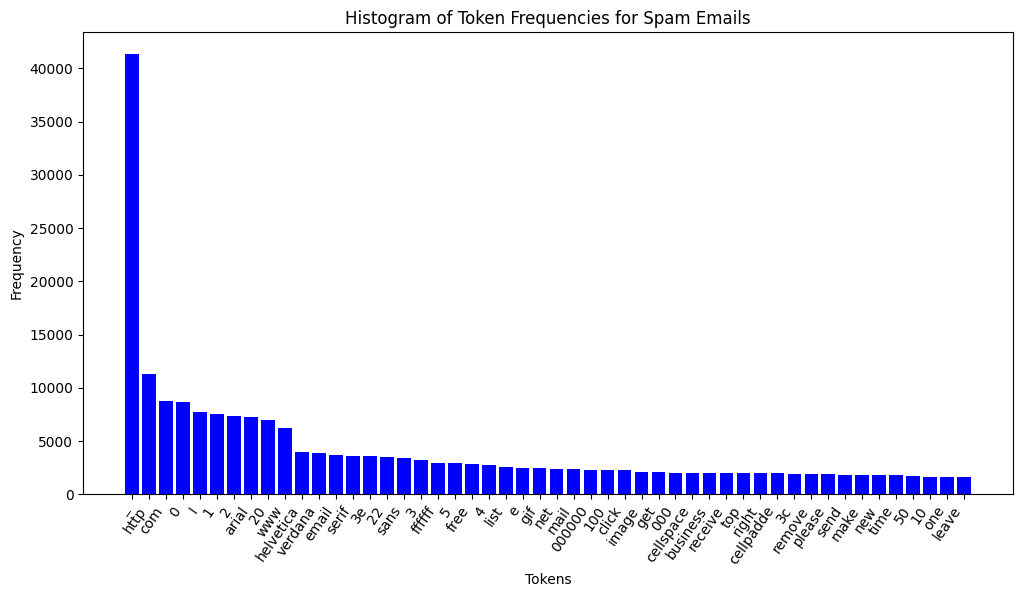

In [15]:
# This extracts the top 50 most frequent tokens (keys) and their corresponding frequencies (values)
keys = list(sorted_tokens.keys())[:50]  # Gets the top 50 tokens
values = list(sorted_tokens.values())[:50]  # Gets the corresponding frequencies of the top 50 tokens

# This sets the figure size for the plot (12 inches wide by 6 inches tall)
plt.figure(figsize=(12, 6))

# This creates a bar chart (histogram) to visualize the token frequencies
# The `keys` are the tokens, and the `values` are their respective frequencies
plt.bar(keys, values, color='blue')

# Adding labels and a title to the plot
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.xticks(rotation=55, ha="right", fontsize=10)
plt.title("Histogram of Token Frequencies for Spam Emails")

# Displays the plot
plt.show()

## Deciding Which Tokens to Count

**Now I'll need to decide which tokens are mainly used in spam emails and append that into the list, and ensure not to keep the tokens that are common between spam and non-spam emails**

### Refining Spam Tokens

To improve the model's ability to detect spam, I'm going to refine the list of `spam_tokens`. The goal is to focus on words and phrases that are highly indicative of spam and less common in legitimate emails. I'll remove some generic terms (like 'http', 'com', common numbers) that can appear in both spam and non-spam, and add more specific spam-related keywords. This should help the model create a more robust distinction between email types.

In [17]:
spam_tokens = [
    # 'free', 'click', 'money', 'offer', 'business', 'receive', 'remove',
    # 'program', 'company', 'service', 'internet', 'product', 'credit', 'price',
    # 'rate', 'software', 'transfer', 'loan', 'guarantee', 'save', 'cash',
    # 'discount', 'marketing', 'urgent', 'deal', 'investment', 'opportunity',
    # 'income', 'financial', 'prize', 'winner', 'congratulations', 'claim',
    # 'account', 'verify', 'password', 'security', 'bank', 'payment', 'unsubscribe',
    # 'scam', 'guaranteed', 'win', 'sex', 'viagra', 'enlarge', 'pharmacy', 'casino',
    # 'lottery', 'congrats', 'now', 'act', 'limited', 'time', 'here',
    # # HTML/formatting elements often found in spam
    # 'arial', 'helvetica', 'verdana', 'serif', 'sans', 'gif', 'image', 'ad',
    # 'mailto', 'million', 'hex', 'ffffff', '000000', 'ff0000', '0033ff', '0000ff',
    # '3e', '22', 'cellspace', 'cellpadde', '3c'
    'free', 'click', 'money', 'offer', 'business', 'receive', 'remove',
    'internet', 'product', 'credit', 'rate', 'loan', 'guarantee', 'save', 'cash',
    'marketing', 'urgent', 'investment', 'prize', 'winner', 'claim',
    'account', 'verify', 'password', 'security', 'bank', 'payment', 'unsubscribe',
    'scam', 'win', 'now', 'limited', 'here', 'http', 'com', 'www', 'net',
    'million', 'dollar', 'gift', 'bonus', 'deal', 'discount'
]

# This creates a dictionary that maps each and every token in the spam_tokens list to a unique index
# The `zip` function pairs each token in the `spam_tokens` list with an index from 0 to the length of `spam_tokens` - 1
token_to_index_mapping = {t:i for t, i in zip(spam_tokens, range(len(spam_tokens)))}

# This displays the resulting dictionary that maps tokens to their respective indices
token_to_index_mapping

{'free': 0,
 'click': 1,
 'money': 2,
 'offer': 3,
 'business': 4,
 'receive': 5,
 'remove': 6,
 'program': 7,
 'company': 8,
 'service': 9,
 'internet': 10,
 'product': 11,
 'credit': 12,
 'price': 13,
 'rate': 14,
 'software': 15,
 'transfer': 16,
 'loan': 17,
 'guarantee': 18,
 'save': 19,
 'cash': 20,
 'discount': 21,
 'marketing': 22,
 'urgent': 23,
 'deal': 24,
 'investment': 25,
 'opportunity': 26,
 'income': 27,
 'financial': 28,
 'prize': 29,
 'winner': 30,
 'congratulations': 31,
 'claim': 32,
 'account': 33,
 'verify': 34,
 'password': 35,
 'security': 36,
 'bank': 37,
 'payment': 38,
 'unsubscribe': 39,
 'scam': 40,
 'guaranteed': 41,
 'win': 42,
 'sex': 43,
 'viagra': 44,
 'enlarge': 45,
 'pharmacy': 46,
 'casino': 47,
 'lottery': 48,
 'congrats': 49,
 'now': 50,
 'act': 51,
 'limited': 52,
 'time': 53,
 'here': 54,
 'arial': 55,
 'helvetica': 56,
 'verdana': 57,
 'serif': 58,
 'sans': 59,
 'gif': 60,
 'image': 61,
 'ad': 62,
 'mailto': 63,
 'million': 64,
 'hex': 65,
 'ff

**Now I'll define a function that will count the number of tokens that we have defined in a given message, using a count vector**

In [42]:
def message_to_count_vector(message):

    # This converts a message into a count vector representation based on predefined spam tokens.

    count_vector = np.zeros(len(spam_tokens))  # This initializes a zero vector with the length of spam_tokens

    processed_list_of_tokens = message_to_token_list(message)  # This tokenizes and preprocesses the message

    for token in processed_list_of_tokens:  # This iterates through each token in the message
        if token not in spam_tokens:  # Skips tokens that are not in the spam token list
            continue
        index = token_to_index_mapping[token]  # Gets the index of the token in the spam token list
        count_vector[index] += 1  # Increments the count at the corresponding index

    return count_vector  # Return the final count vector

# This is the example message to test it on:
message_to_count_vector('arial hi click on this free gif deal')

array([1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0.])

Now I will split the data into **train and test**

In [43]:
# This shuffles the dataset randomly while still preserving the full dataset size
df = df.sample(frac=1, random_state=1)

# This reset the index after shuffling, and drops the old index
df = df.reset_index(drop=True)

# This determines the split index for an 80%-20% train-test split
split_index = int(len(df) * 0.8)

# Split the shuffled dataset into training (80%) and testing (20%) sets
train_df, test_df = df[:split_index], df[split_index:]

# Resets the index for the training set
train_df = train_df.reset_index(drop=True)

# Resets the index for the testing set
test_df = test_df.reset_index(drop=True)

# Prints the shape (rows, columns) of the training and testing datasets
print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)

train_df shape: (4636, 3)
test_df shape: (1160, 3)


Now I'll **reveal the count vector for one of the emails from the dataset** and see **how many of the words from the `spam_tokens` list is in the email**

In [44]:
# Train dataset's index that you are viewing
index = 3

# View the count vector of one of the emails in the train dataset
message_to_count_vector(train_df['MESSAGE'].iloc[index])

array([ 0.,  4.,  0.,  0.,  2.,  1.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,
        1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  1.,  0.,  1.,  0., 12.,  1.,  0.,  3.,  8.,  0.,  1.,  0.,
        0.,  1.,  1.,  5.,  0.,  2.,  0.,  0.,  1.,  1.,  0.])

In [45]:
#Revealing whether the mail is spam on not

train_df.iloc[index]

,3
CATEGORY,1
MESSAGE,\n\n<HTML>\n\n<HEAD>\n\n<TITLE>bizmagoffer</TI...
FILE_NAME,00627.4e9619c454da17a27d4a66c87583dd49


In [46]:
  # Viewing the message
print(train_df.iloc[index]['MESSAGE'])



<HTML>

<HEAD>

<TITLE>bizmagoffer</TITLE>

<META HTTP-EQUIV="Content-Type" CONTENT="text/html; charset=iso-8859-1">

</HEAD>

<BODY BGCOLOR=#FFFFFF>

<center>

<TABLE WIDTH=392 BORDER=0 CELLPADDING=0 CELLSPACING=0>

	<TR>

		<TD COLSPAN=3>

            <h1 align="center"><b><font color="#FF0000" face="Verdana">Knowledge Is Power!</font></b></h1>

        </TD>

	</TR>

	<TR>

		<TD COLSPAN=3>

            <center><font face="Verdana" color="#0000FF" size="4"><b>So Get Yours At A Savings Up To 78%</b></font></center>

        </TD>

	</TR>

	<TR>

		<TD COLSPAN=3>

            <center><font face="Verdana" color="#000000"><b>On The Top Informative Business Magazines</b></font></center>

        </TD>

	</TR>

	<TR>

		<TD COLSPAN=3>

			<IMG SRC="http://www.global2000.com/creatives/mag/images/bizmag_02.jpg" WIDTH=392 HEIGHT=137></TD>

	</TR>

	<TR>

		<TD COLSPAN=3>

			<IMG SRC="http://www.global2000.com/creatives/mag/images/bizmag_03.gif" WIDTH=392 HEIGHT=17></TD>

	</TR>

	<TR>

		

## Now we will convert all of our emails into numerical data

I'm doing this because **Machine learning models only understand numerical data, not raw text.** Therefore, I'm **converting emails into numerical representations (like count vectors) to allow the models to learn patterns and classify them**, for example, as spam or non-spam.

In [47]:
def df_to_X_y(dff):
    # This function converts the email text into numerical counts (X) and extracts the labels (y).
    # It prepares the data so the machine learning models can process and learn from it.

    # Extracts the target variable ('CATEGORY') and converts it to a NumPy array of integers
    y = dff['CATEGORY'].to_numpy().astype(int)

    # THis extracts the 'MESSAGE' column containing text data
    message_col = dff['MESSAGE']

    # An empty list is made here to store count vector representations of messages
    count_vectors = []

    # This iterates through each message in the column
    for message in message_col:
        # Converts the message into a count vector representation
        count_vector = message_to_count_vector(message)

        # This code appends the vector to the list
        count_vectors.append(count_vector)

    # This code converts the list of count vectors into a NumPy array and ensures it is of type 'int'
    X = np.array(count_vectors).astype(int)

    # Return the feature matrix (X) and target array (y)
    return X, y

In [48]:
# This converts the training DataFrame into a feature matrix (X_train) and target array (y_train)
X_train, y_train = df_to_X_y(train_df)

# This converts the testing DataFrame into feature matrix (X_test) and target array (y_test)
X_test, y_test = df_to_X_y(test_df)

# Displays the shapes of the feature matrices and target arrays
# This helps verify the correctness of the data transformation process
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((4636, 76), (4636,), (1160, 76), (1160,))

## Scaling the Data

Now I'm going to scale the data so that all of the values are between 0 and 1

In [49]:
# Now initializing a MinMaxScaler and fitting it into the training data
# The MinMaxScaler scales each feature to a given range (default: 0 to 1)
scaler = MinMaxScaler().fit(X_train)

# This transforms both the training and testing data using the fitted scaler
# This ensures that both datasets are scaled consistently
X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)

# This displays the transformed training feature matrix
X_train

array([[0.04761905, 0.        , 0.02702703, ..., 0.        , 0.        ,
        0.        ],
       [0.02380952, 0.03571429, 0.08108108, ..., 0.        , 0.        ,
        0.        ],
       [0.02380952, 0.        , 0.        , ..., 0.02777778, 0.02777778,
        0.        ],
       ...,
       [0.        , 0.39285714, 0.        , ..., 0.08333333, 0.08333333,
        0.        ],
       [0.02380952, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

## Now training and evaluating the model so its ready for real world scenarios!!!

**First I'm going to try training a logistic regression model and see how the accuracy is**

In [50]:
# Initialize and train a logistic regression model using the training data
lr = LogisticRegression().fit(X_train, y_train)

# print a classification report
# The report has precision, recall, F1-score, and the support for each class
print("Logistic Regression Classification Report:")
print(classification_report(y_test, lr.predict(X_test)))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       790
           1       0.96      0.59      0.73       370

    accuracy                           0.86      1160
   macro avg       0.90      0.79      0.82      1160
weighted avg       0.87      0.86      0.85      1160



**Next I'm going to try training a random forest classifier model to see how it performs**

In [51]:
# Initialize and train a random forest classifier using the training data
rf = RandomForestClassifier().fit(X_train, y_train)

# print a classification report
# The report has precision, recall, F1-score, and the support for each class
print("Random Forest Classifier Classification Report:")
print(classification_report(y_test, rf.predict(X_test)))

Random Forest Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       790
           1       0.92      0.89      0.91       370

    accuracy                           0.94      1160
   macro avg       0.94      0.93      0.93      1160
weighted avg       0.94      0.94      0.94      1160



**Now I'm training a Support Vector Classifier model to see how it performs**

In [52]:
# Initialize and train a Support Vector Classifier (SVC) using the training data
# We set probability=True to allow for probability estimates, though not directly used in classification_report.
# A linear kernel is chosen for this high-dimensional data.
svc = SVC(kernel='rbf', random_state=1, probability=True).fit(X_train, y_train)

# print a classification report
# The report has precision, recall, F1-score, and the support for each classand support for each class
print("Support Vector Machine (SVC) Classification Report:")
print(classification_report(y_test, svc.predict(X_test)))

Support Vector Machine (SVC) Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       790
           1       0.90      0.75      0.82       370

    accuracy                           0.89      1160
   macro avg       0.90      0.86      0.87      1160
weighted avg       0.89      0.89      0.89      1160



**Moving on to training a Naive Bayes model and seeing how it performes**

In [53]:
# Initialize and train a Multinomial Naive Bayes model using the training data
# Alpha is a smoothing parameter (0 for no smoothing, 1 for Laplace smoothing).
mnb = MultinomialNB(alpha=1.0).fit(X_train, y_train)

# print a classification report
# The report has precision, recall, F1-score, and the support for each class
print("Multinomial Naive Bayes Classification Report:")
print(classification_report(y_test, mnb.predict(X_test)))

Multinomial Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84       790
           1       1.00      0.19      0.33       370

    accuracy                           0.74      1160
   macro avg       0.86      0.60      0.58      1160
weighted avg       0.81      0.74      0.68      1160



## Now I'm going visualize how each model did in predicting the spam and not spam emails!

I cannot retrain or visualize Multinomial Naive Bayes on this Principal Component Analysis-reduced dataset(transform a high-dimensional dataset into a lower-dimensional form) because Multinomial Naive Bayes is not suitable for PCA-transformed data as PCA can produce negative values, while Multinomial Naive Bayes requires non-negative input (mainly for the count data).

### Dimensionality Reduction for Visualization

To visualize the decision boundaries of each model in 2D, I will need to reduce the dimensionality of the feature space. I'll use Principal Component Analysis to project the 95-feature data down to 2 principal components.

In [54]:
from sklearn.decomposition import PCA

# Initializing the PCA to reduce the data to 2 principal components
pca = PCA(n_components=2)

# Fitting the PCA on the training data and then transforming both the training and testing data
# This projects the high-dimensional data into a 2D space
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Shape of PCA-transformed training data:", X_train_pca.shape)
print("Shape of PCA-transformed testing data:", X_test_pca.shape)

Shape of PCA-transformed training data: (4636, 2)
Shape of PCA-transformed testing data: (1160, 2)


### Retraining Models on PCA-transformed Data

Since I've reduced the data's dimensionality, I will need to retrain the models on this new 2D representation before I can visualize their decision boundaries.

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Retraining the Logistic Regression model using the 2-dimensional PCA-transformed training data
lr_pca = LogisticRegression(random_state=1).fit(X_train_pca, y_train)

# Retraining the Random Forest Classifier model using the 2-dimensional PCA-transformed training data
rf_pca = RandomForestClassifier(random_state=1).fit(X_train_pca, y_train)

# Retraining the Support Vector Classifier model using the 2-dimensional PCA-transformed training data
svc_pca = SVC(kernel='rbf', random_state=1).fit(X_train_pca, y_train)

print("Logistic Regression (PCA) model training complete.")
print("Random Forest (PCA) model training complete.")
print("Support Vector Classifier (PCA) model training complete.")

Logistic Regression (PCA) model training complete.
Random Forest (PCA) model training complete.
Support Vector Classifier (PCA) model training complete.


### Visualizing the Logistic Regression Model's Decision Boundary

This plot here shows the decision boundary drawn by the Logistic Regression model in the 2D PCA space. Logistic regression calculates the probability that an input belongs to a specific category by passing a linear equation's output through a sigmoid function, which squeezes the result into a value between 0 and 1.

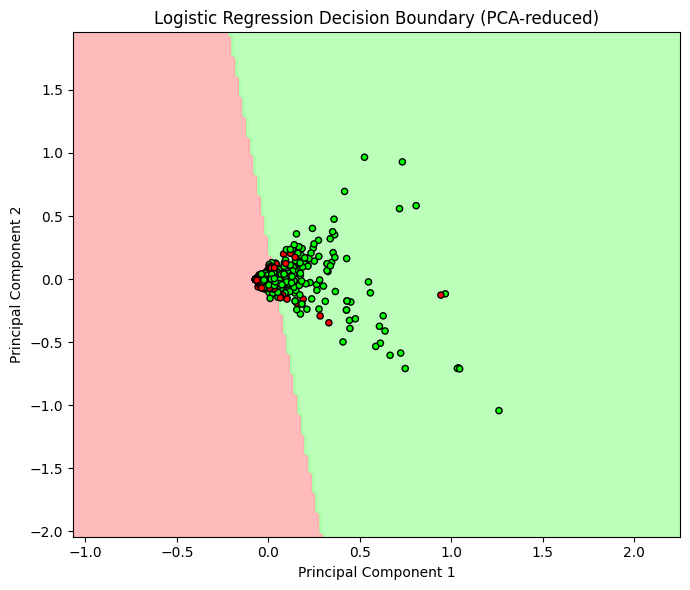

In [56]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np # Import numpy as it's used for meshgrid

# Defining the color maps for the background and data points
cmp_light = ListedColormap(['#FFAAAA', '#AAFFaa']) # Light colors for decision regions
cmp_dark = ListedColormap(['#FF0000', '#00FF00'])  # Dark colors for actual data points

# This determines the min and max values for the plot axes, adding a small margin
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1

# Creates a meshgrid (a grid of points) across the plot area
# This grid is used to predict a class for every point, thus mapping the decision regions
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

plt.figure(figsize=(7, 6))

# This predicts the class for each point in the meshgrid using the Logistic Regression model
Z_lr = lr_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z_lr = Z_lr.reshape(xx.shape) # Reshape the predictions to match the meshgrid dimensions

# Plot the decision regions as a filled contour plot
plt.contourf(xx, yy, Z_lr, cmap=cmp_light, alpha=0.8)

# Plot the actual test data points, colored by their true labels (y_test)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap=cmp_dark, s=20, edgecolor='k')

# Add labels and a title to the plot
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Logistic Regression Decision Boundary (PCA-reduced)')

plt.tight_layout() # Adjust plot to prevent labels from overlapping
plt.show()

### Visualizing the Support Vector Machine Model's Decision Boundary

This plot shows the decision boundary drawn by the Support Vector Machine model in the 2D PCA space. The background colors represent the regions where the model predicts 'non-spam emails' (light red) or 'spam emails' (light green), and the dots are the actual test data points (red for spam, green for non-spam). SVMs try to find the best dividing line or boundary between different categories of data by maximizing the empty space (margin) between the closest points of those categories, and with a linear kernel, it will attempt to find a linear boundary in this reduced dimension.

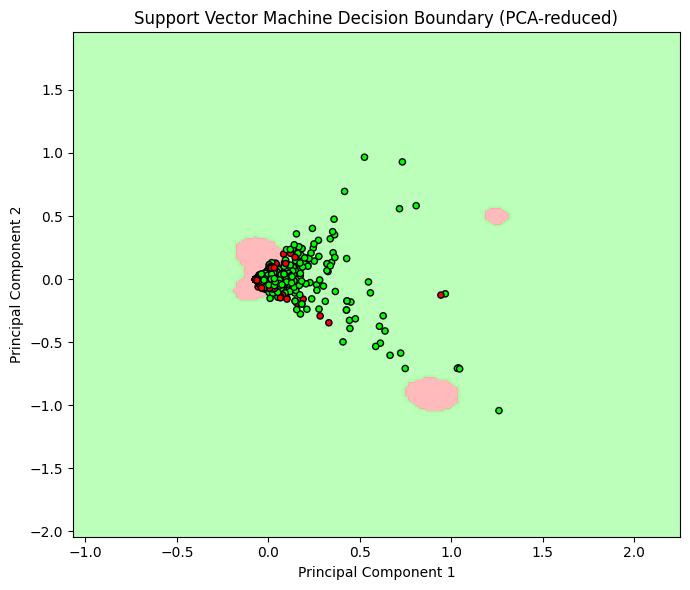

In [57]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

cmp_light = ListedColormap(['#FFAAAA', '#AAFFaa'])
cmp_dark = ListedColormap(['#FF0000', '#00FF00'])

x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

plt.figure(figsize=(7, 6))

# Predicts the class for each point in the meshgrid using the SVC model
Z_svc = svc_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z_svc = Z_svc.reshape(xx.shape)

plt.contourf(xx, yy, Z_svc, cmap=cmp_light, alpha=0.8)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap=cmp_dark, s=20, edgecolor='k')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Support Vector Machine Decision Boundary (PCA-reduced)')

plt.tight_layout()
plt.show()

### Visualizing Random Forest Classifier Decision Boundary

This plot displays the decision boundary for the Random Forest Classifier in the same 2D PCA space. A Random Forest Classifier works by training multiple independent decision trees on random subsets of data and features, then combining their individual predictions through a majority vote to determine the final class. See how it creates a more complex, non-linear boundary compared to Logistic Regression and SVM. This is the reason it has a higher accuracy.

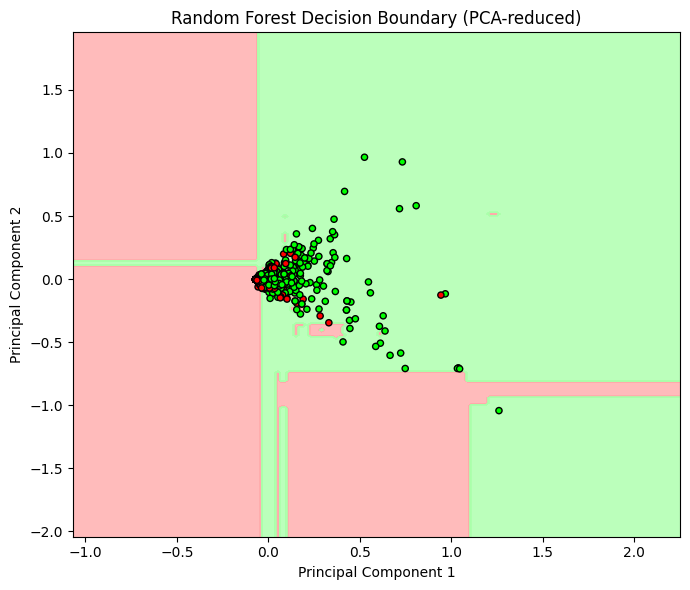

In [58]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

cmp_light = ListedColormap(['#FFAAAA', '#AAFFaa'])
cmp_dark = ListedColormap(['#FF0000', '#00FF00'])


x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1


xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

plt.figure(figsize=(7, 6))

# Predicts the class for each point in the meshgrid using the Random Forest Classifier model
Z_rf = rf_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rf = Z_rf.reshape(xx.shape)


plt.contourf(xx, yy, Z_rf, cmap=cmp_light, alpha=0.8)

plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap=cmp_dark, s=20, edgecolor='k')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Random Forest Decision Boundary (PCA-reduced)')

plt.tight_layout() # Adjust plot to prevent labels from overlapping
plt.show()

## It's your chance to try and make an email that could look like spam or be non-spam, and the Random Forest Classifier Model will predict whether it was spam or not.

In [64]:
user_email = input("Enter your email: ")

# Preprocess and scale
custom_vector = message_to_count_vector(user_email).reshape(1, -1)
custom_scaled = scaler.transform(custom_vector)

# Predict
prediction = rf.predict(custom_scaled)[0]

# Simple output
print("SPAM" if prediction == 1 else "NOT SPAM")

Enter your email: yo click here for free money along with 1 million dollars in you bank account with free food, drinks, and everything you would ever want. limited seats only
NOT SPAM


## Now you get to play a game: Human vs Random Forest Classifier model!

In this game I'll show you an email, and you will have to predict if it's spam by pressing [1] or not spam by pressing [0], and then I'll reveal the model's prediction and the true label and you can see whether you ended up beating the model or not.

In [62]:
# Import necessary libraries for interactive input
from IPython.display import display, HTML
import random

def play_spam_game():
    # Play the spam prediction game against the Random Forest model
    while True:
        # Select a random email from the test dataset
        random_index = random.randint(0, len(test_df) - 1)
        email_message = test_df.iloc[random_index]['MESSAGE']
        true_label = test_df.iloc[random_index]['CATEGORY']

        # Display the email to the user
        print("\n---New Email---")
        print("Read the following email and predict if it's spam or not.")
        print("\n" + email_message)
        print("\n-------------------")

        # Get user's prediction
        user_prediction_input = input("Enter your prediction (0 for Not Spam, 1 for Spam): ")
        try:
            user_prediction = int(user_prediction_input)
            if user_prediction not in [0, 1]:
                raise ValueError
        except ValueError:
            print("Invalid input. Please enter 0 or 1.")
            continue

        # Preprocess the email for the model
        # Convert message to count vector
        email_vector = message_to_count_vector(email_message)
        # Reshape for single sample prediction
        email_vector_reshaped = email_vector.reshape(1, -1)
        # Scale the vector using the fitted scaler
        email_scaled = scaler.transform(email_vector_reshaped)

        # Get the Random Forest model's prediction
        model_prediction = rf.predict(email_scaled)[0]

        # Reveal results
        print("\n--- Results ---")
        print(f"Your Prediction: {'Spam' if user_prediction == 1 else 'Not Spam'}")
        print(f"Model's Prediction: {'Spam' if model_prediction == 1 else 'Not Spam'}")
        print(f"Actual Label: {'Spam' if true_label == 1 else 'Not Spam'}")

        # Compare predictions
        if user_prediction == true_label:
            print("You were CORRECT!")
        else:
            print("You were INCORRECT.")

        if model_prediction == true_label:
            print("The model was CORRECT!")
        else:
            print("The model was INCORRECT.")

        # Ask if the user wants to play again
        play_again = input("\nDo you want to play again? (yes/no): ").lower()
        if play_again != 'yes':
            print("Thanks for playing!")
            break

# Start the game
play_spam_game()


---New Email---
Read the following email and predict if it's spam or not.



<HTML><HEAD><TITLE></TITLE></HEAD><BODY BGCOLOR="WHITE">

<TABLE WIDTH=550><TR><TD><FONT SIZE=4 FACE="VERDANA" COLOR="#333366">



Have tax problems? Do you owe the IRS money? If your debt is

$5,000 US or more, we can help! Our licensed agents can help

you with both past and present tax debt. We have direct contacts

with the IRS, so once your application is processed we can help

you immediately without further delay.<BR><BR>



Also, as our client we can offer you other services and help with

other problems. Our nationally recognized tax attorneys,

paralegals, legal assistants and licensed enrolled agents can

help you with:<BR><BR>



- Tax Preparation<BR>

- Audits<BR>

- Seizures<BR>

- Bank Levies<BR>

- Asset Protection<BR>

- Audit Reconsideration<BR>

- Trust Fund Penalty Defense<BR>

- Penalty Appeals<BR>

- Penalty Abatement<BR>

- Wage Garnishments<BR>

.. and more!<BR><BR>



To receive FREE 